In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

print("Libraries imported successfully")


Libraries imported successfully


In [3]:
DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"

train = pd.read_csv(f"{DATA_DIR}/train.csv", low_memory=False)
test = pd.read_csv(f"{DATA_DIR}/test.csv", low_memory=False)
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv", low_memory=False)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Target column(s):", set(train.columns) - set(test.columns))


Train shape: (138701, 50)
Test shape : (15000, 49)
Target column(s): {'TargetValue'}


In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


In [7]:
print("Duplicate rows:", train.duplicated().sum())
print("\nUnique value counts (top 15 columns):")
train.nunique().sort_values(ascending=False).head(15)


Duplicate rows: 0

Unique value counts (top 15 columns):


TransactionID               138701
AssetID                     120111
OperationalHoursMeter        14643
TransactionDate               3676
ProductConfigID               3594
Spec_FullDescriptor           3505
Spec_BaseClass                1249
TargetValue                    675
Spec_SubClass                  147
Spec_VariantModifier           132
Spec_ReleaseSeries             113
ManufactureYear                 68
FunctionalClassification        65
RegionCode                      53
VendorPartnerID                 31
dtype: int64

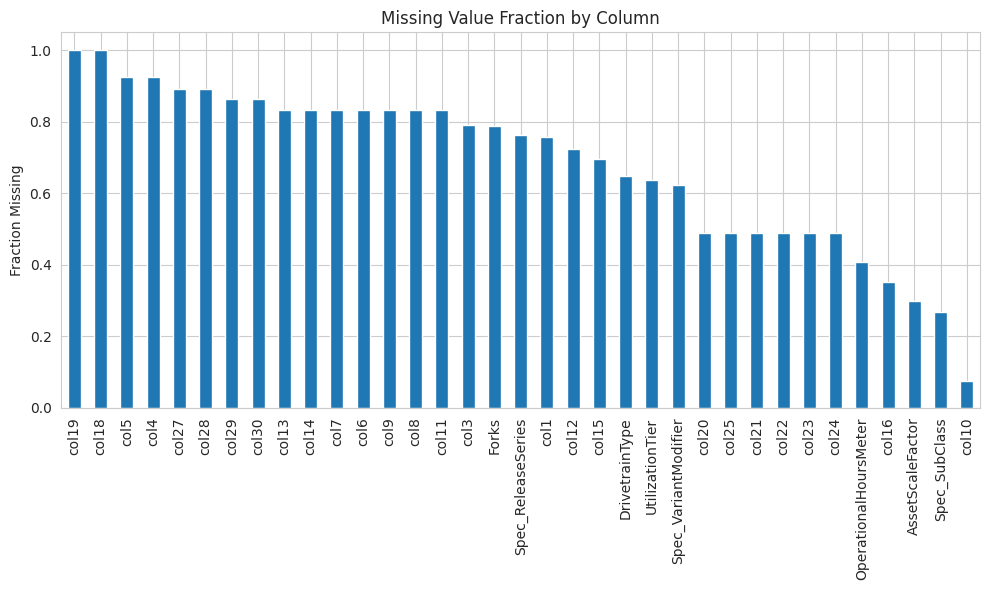

col19                 0.999524
col18                 0.999524
col5                  0.925156
col4                  0.925156
col27                 0.892149
col28                 0.892149
col29                 0.863938
col30                 0.863938
col13                 0.831256
col14                 0.831256
col7                  0.831256
col6                  0.831256
col9                  0.831256
col8                  0.831256
col11                 0.831256
col3                  0.789093
Forks                 0.788617
Spec_ReleaseSeries    0.762828
col1                  0.756411
col12                 0.723405
dtype: float64

In [8]:
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
missing.plot.bar()
plt.ylabel("Fraction Missing")
plt.title("Missing Value Fraction by Column")
plt.tight_layout()
plt.show()

missing.head(20)


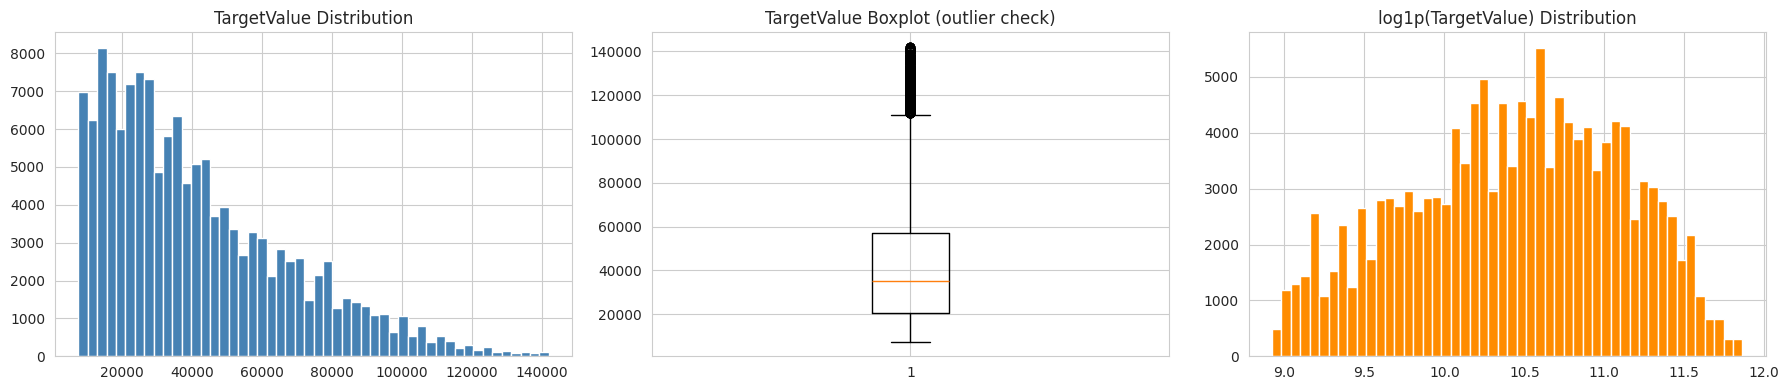

Skew (raw): 0.97
Skew (log1p): -0.2


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(train["TargetValue"], bins=50, color="steelblue")
axes[0].set_title("TargetValue Distribution")

axes[1].boxplot(train["TargetValue"].dropna())
axes[1].set_title("TargetValue Boxplot (outlier check)")

axes[2].hist(np.log1p(train["TargetValue"]), bins=50, color="darkorange")
axes[2].set_title("log1p(TargetValue) Distribution")

plt.tight_layout()
plt.show()

print("Skew (raw):", train["TargetValue"].skew().round(2))
print("Skew (log1p):", np.log1p(train["TargetValue"]).skew().round(2))


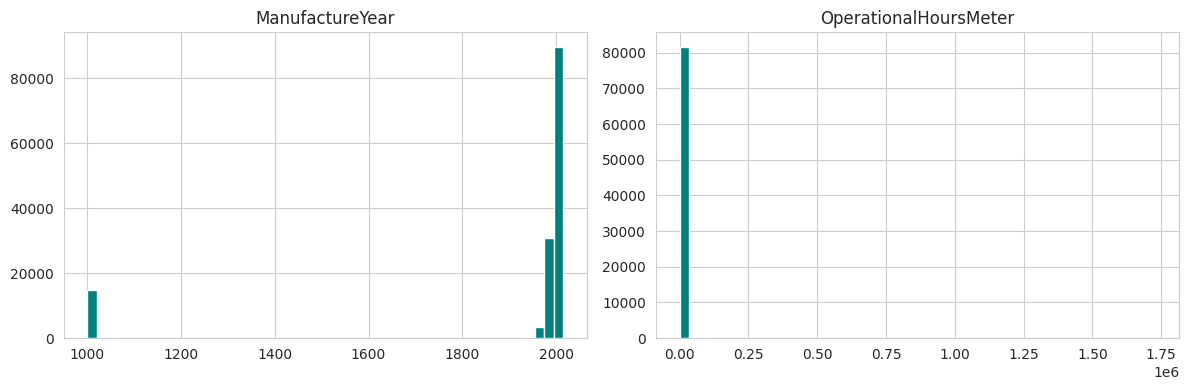

In [10]:
numeric_cols_preview = ["ManufactureYear", "OperationalHoursMeter"]
numeric_cols_preview = [c for c in numeric_cols_preview if c in train.columns]

fig, axes = plt.subplots(1, len(numeric_cols_preview), figsize=(6 * len(numeric_cols_preview), 4))
if len(numeric_cols_preview) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols_preview):
    ax.hist(train[col].dropna(), bins=50, color="teal")
    ax.set_title(col)

plt.tight_layout()
plt.show()


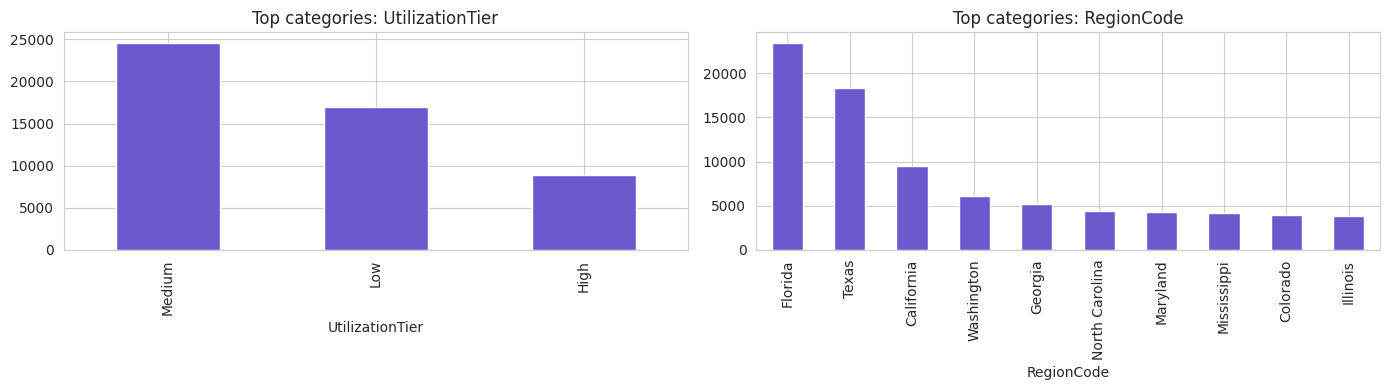

In [11]:
cat_cols_preview = ["UtilizationTier", "RegionCode"]
cat_cols_preview = [c for c in cat_cols_preview if c in train.columns]

fig, axes = plt.subplots(1, len(cat_cols_preview), figsize=(7 * len(cat_cols_preview), 4))
if len(cat_cols_preview) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_preview):
    train[col].value_counts().head(10).plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title(f"Top categories: {col}")

plt.tight_layout()
plt.show()


In [12]:
num_df = train.select_dtypes(include=["int64", "float64"])
corr = num_df.corr(numeric_only=True)["TargetValue"].sort_values(ascending=False)
print("Correlation with TargetValue:")
corr.head(15)


Correlation with TargetValue:


TargetValue              1.000000
ManufactureYear          0.204439
ProductConfigID          0.057265
OperationalHoursMeter    0.001994
TransactionID           -0.012093
AssetID                 -0.238719
Name: TargetValue, dtype: float64

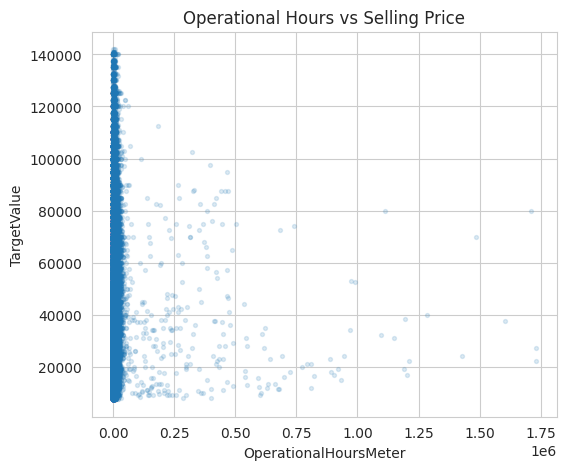

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(train["OperationalHoursMeter"], train["TargetValue"], alpha=0.15, s=8)
plt.xlabel("OperationalHoursMeter")
plt.ylabel("TargetValue")
plt.title("Operational Hours vs Selling Price")
plt.show()


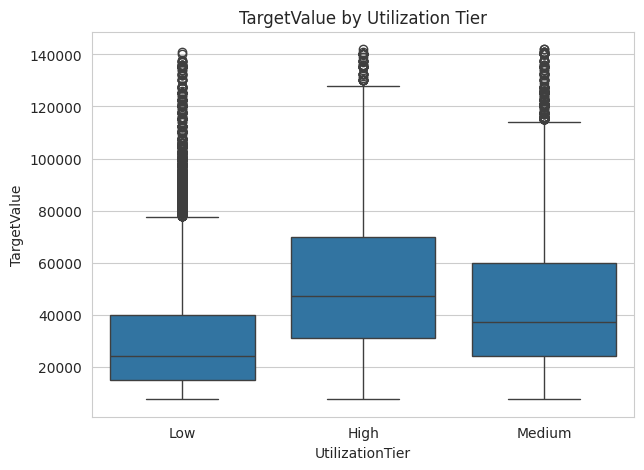

In [14]:
if "UtilizationTier" in train.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=train, x="UtilizationTier", y="TargetValue")
    plt.title("TargetValue by Utilization Tier")
    plt.show()


In [15]:
# ====================================
# Drop Columns with >80% Missing Values
# ====================================

missing_percent = train.isnull().mean()

drop_cols = missing_percent[missing_percent > 0.80].index.tolist()

print("Columns to Drop:")
print(drop_cols)

train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True, errors="ignore")

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Columns to Drop:
['col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']
Train Shape: (138701, 35)
Test Shape : (15000, 34)


In [16]:
# ====================================
# Feature Engineering Function
# ====================================

def feature_engineering(df):

    df = df.copy()

    # Convert Date
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

    # Date Features
    df["SaleYear"] = df["TransactionDate"].dt.year
    df["SaleMonth"] = df["TransactionDate"].dt.month
    df["SaleDay"] = df["TransactionDate"].dt.day
    df["SaleDayOfWeek"] = df["TransactionDate"].dt.dayofweek
    df["SaleQuarter"] = df["TransactionDate"].dt.quarter

    # Replace Invalid Year
    df["ManufactureYear"] = df["ManufactureYear"].replace([1000,1001],np.nan)

    # Machine Age
    df["MachineAge"] = (
        df["SaleYear"] -
        df["ManufactureYear"]
    )

    # Usage Intensity
    df["HoursPerYear"] = (
        df["OperationalHoursMeter"] /
        df["MachineAge"].replace(0,np.nan)
    )

    # Drop Original Date
    df.drop(columns=["TransactionDate"],inplace=True)

    return df

   

In [17]:
# ====================================
# ADDITIONAL FEATURE ENGINEERING (v3)
# ====================================

def feature_engineering_v3(df):
    df = df.copy()

    # Clip absurd MachineAge caused by bad ManufactureYear data
    if "MachineAge" in df.columns:
        df["MachineAge"] = df["MachineAge"].clip(lower=0, upper=60)
        df["AgeBucket"] = pd.cut(
            df["MachineAge"],
            bins=[-1, 2, 5, 10, 15, 20, 30, 100],
            labels=["0-2", "3-5", "6-10", "11-15", "16-20", "21-30", "30+"]
        ).astype(str)

    # Log-transform skewed numeric columns
    for col in ["OperationalHoursMeter", "HoursPerYear"]:
        if col in df.columns:
            df[col + "_log"] = np.log1p(df[col].clip(lower=0))

    # Extra date signal
    if "SaleDayOfWeek" in df.columns:
        df["IsWeekendSale"] = (df["SaleDayOfWeek"] >= 5).astype(int)

    # ---- Missing-value indicator flags ----
    # Missingness itself can carry signal (e.g. spec fields missing more often on
    # older/cheaper equipment). Flag the columns that actually had missing values in train.
    cols_with_na = [c for c in df.columns if df[c].isnull().any()]
    for c in cols_with_na:
        df[c + "_was_missing"] = df[c].isnull().astype(int)

    # ---- A couple of safe interaction features (no target leakage) ----
    if "MachineAge" in df.columns and "OperationalHoursMeter" in df.columns:
        df["Age_x_Hours"] = df["MachineAge"].fillna(0) * np.log1p(df["OperationalHoursMeter"].clip(lower=0))

    return df


train = feature_engineering_v3(train)
test = feature_engineering_v3(test)

print("Train shape after v3 FE:", train.shape)
print("Test shape after v3 FE :", test.shape)


Train shape after v3 FE: (138701, 57)
Test shape after v3 FE : (15000, 56)


In [18]:
# ====================================
# TARGET OUTLIER HANDLING
# ====================================
low_clip = train["TargetValue"].quantile(0.005)
high_clip = train["TargetValue"].quantile(0.995)
print(f"Clipping TargetValue to [{low_clip:.0f}, {high_clip:.0f}]")
train["TargetValue"] = train["TargetValue"].clip(low_clip, high_clip)


Clipping TargetValue to [8000, 125000]


In [19]:
X = train.drop("TargetValue", axis=1)
y = np.log1p(train["TargetValue"])

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# High-cardinality categoricals get target encoding (done fold-safe below);
# everything else still goes through ordinal encoding in the pipeline.
high_card_cols = [c for c in categorical_features if X[c].nunique() > 20]
print("Target-encoding these high-cardinality columns:", high_card_cols)
print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))


Target-encoding these high-cardinality columns: ['VendorPartnerID', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification', 'RegionCode', 'col22']
Numeric Features: 27
Categorical Features: 29


In [20]:
def target_encode_fold(X_tr, X_va, X_test, y_tr, cols, smoothing=10):
    X_tr, X_va, X_test = X_tr.copy(), X_va.copy(), X_test.copy()
    global_mean = y_tr.mean()
    for c in cols:
        stats = y_tr.groupby(X_tr[c]).agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        X_tr[c + "_te"] = X_tr[c].map(smoothed).fillna(global_mean)
        X_va[c + "_te"] = X_va[c].map(smoothed).fillna(global_mean)
        X_test[c + "_te"] = X_test[c].map(smoothed).fillna(global_mean)
    return X_tr, X_va, X_test


In [21]:
# ====================================
# 5-FOLD CV: LightGBM  (early stopping now actually works)
# ====================================
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import lightgbm as lgb
import numpy as np

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
test_lgb_preds = np.zeros(len(test))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    test_fold = test.copy()

    # leak-safe target encoding computed on this fold's training data only
    X_tr, X_va, test_fold = target_encode_fold(X_tr, X_va, test_fold, y_tr, high_card_cols)

    fold_numeric = numeric_features + [c + "_te" for c in high_card_cols]
    fold_categorical = categorical_features  # still ordinal-encoded as a backup signal

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, fold_numeric),
        ("cat", categorical_pipeline, fold_categorical)
    ])

    X_tr_p = preprocessor.fit_transform(X_tr)
    X_va_p = preprocessor.transform(X_va)
    test_p = preprocessor.transform(test_fold)

    model = LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42 + fold,
        n_jobs=-1
    )
    model.fit(
        X_tr_p, y_tr,
        eval_set=[(X_va_p, y_va)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)]
    )

    oof_lgb[va_idx] = model.predict(X_va_p)
    test_lgb_preds += model.predict(test_p) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_va, oof_lgb[va_idx]))
    print(f"Fold {fold+1} LGB RMSE: {fold_rmse:.5f}  (best_iteration={model.best_iteration_})")

lgb_oof_rmse = np.sqrt(mean_squared_error(y, oof_lgb))
print("\nOverall LGB OOF RMSE:", lgb_oof_rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3980
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 66
[LightGBM] [Info] Start training from score 10.424630
Fold 1 LGB RMSE: 0.21626  (best_iteration=1003)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3978
[LightGBM] [Info] Number of data points in the train set: 110961, number of used features: 66
[LightGBM] [Info] Start training from score 10.424215
Fold 2 LGB RMSE: 0.21956  (best_iteration=1200)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.

In [22]:
# ====================================
# 5-FOLD CV: CatBoost (native categorical handling + speed flags)
# ====================================
from catboost import CatBoostRegressor

X_cat_full = X.copy()
test_cat_full = test.copy()

for col in X_cat_full.columns:
    if X_cat_full[col].dtype == "object":
        X_cat_full[col] = X_cat_full[col].fillna("Missing").astype(str)
        test_cat_full[col] = test_cat_full[col].fillna("Missing").astype(str)

cat_feature_names = X_cat_full.select_dtypes(include="object").columns.tolist()

oof_cat = np.zeros(len(X_cat_full))
test_cat_preds = np.zeros(len(test_cat_full))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_cat_full)):
    X_tr, X_va = X_cat_full.iloc[tr_idx].copy(), X_cat_full.iloc[va_idx].copy()
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    test_fold = test_cat_full.copy()

    for col in X_tr.columns:
        if X_tr[col].dtype != "object":
            med = X_tr[col].median()
            X_tr[col] = X_tr[col].fillna(med)
            X_va[col] = X_va[col].fillna(med)
            test_fold[col] = test_fold[col].fillna(med)

    model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.04,
        depth=7,
        l2_leaf_reg=5,
        boosting_type="Plain",
        bootstrap_type="Bernoulli",
        subsample=0.8,
        rsm=0.8,
        one_hot_max_size=10,
        random_seed=42 + fold,
        loss_function="RMSE",
        eval_metric="RMSE",
        early_stopping_rounds=100,
        thread_count=-1,
        verbose=False
    )
    model.fit(
        X_tr, y_tr,
        cat_features=cat_feature_names,
        eval_set=(X_va, y_va),
        use_best_model=True
    )

    oof_cat[va_idx] = model.predict(X_va)
    test_cat_preds += model.predict(test_fold) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_va, oof_cat[va_idx]))
    print(f"Fold {fold+1} CatBoost RMSE: {fold_rmse:.5f}  (best_iteration={model.get_best_iteration()})")

cat_oof_rmse = np.sqrt(mean_squared_error(y, oof_cat))
print("\nOverall CatBoost OOF RMSE:", cat_oof_rmse)


Fold 1 CatBoost RMSE: 0.23778  (best_iteration=1999)
Fold 2 CatBoost RMSE: 0.24103  (best_iteration=1999)
Fold 3 CatBoost RMSE: 0.24103  (best_iteration=1999)
Fold 4 CatBoost RMSE: 0.24072  (best_iteration=1999)
Fold 5 CatBoost RMSE: 0.23967  (best_iteration=1999)

Overall CatBoost OOF RMSE: 0.24005060776824588


In [23]:
# ====================================
# 5-FOLD CV: XGBoost (3rd diverse model for the ensemble)
# ====================================
from xgboost import XGBRegressor

oof_xgb = np.zeros(len(X))
test_xgb_preds = np.zeros(len(test))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    test_fold = test.copy()

    X_tr, X_va, test_fold = target_encode_fold(X_tr, X_va, test_fold, y_tr, high_card_cols)

    fold_numeric = numeric_features + [c + "_te" for c in high_card_cols]
    fold_categorical = categorical_features

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, fold_numeric),
        ("cat", categorical_pipeline, fold_categorical)
    ])

    X_tr_p = preprocessor.fit_transform(X_tr)
    X_va_p = preprocessor.transform(X_va)
    test_p = preprocessor.transform(test_fold)

    model = XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5,
        random_state=42 + fold,
        n_jobs=-1,
        tree_method="hist",
        early_stopping_rounds=100,
        eval_metric="rmse"
    )
    model.fit(X_tr_p, y_tr, eval_set=[(X_va_p, y_va)], verbose=False)

    oof_xgb[va_idx] = model.predict(X_va_p)
    test_xgb_preds += model.predict(test_p) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_va, oof_xgb[va_idx]))
    print(f"Fold {fold+1} XGBoost RMSE: {fold_rmse:.5f}  (best_iteration={model.best_iteration})")

xgb_oof_rmse = np.sqrt(mean_squared_error(y, oof_xgb))
print("\nOverall XGBoost OOF RMSE:", xgb_oof_rmse)


Fold 1 XGBoost RMSE: 0.20073  (best_iteration=2980)
Fold 2 XGBoost RMSE: 0.20379  (best_iteration=2992)
Fold 3 XGBoost RMSE: 0.20405  (best_iteration=2997)
Fold 4 XGBoost RMSE: 0.20417  (best_iteration=2993)
Fold 5 XGBoost RMSE: 0.20356  (best_iteration=2966)

Overall XGBoost OOF RMSE: 0.20326556703058152


In [24]:
from sklearn.linear_model import RidgeCV

oof_stack = np.column_stack([oof_lgb, oof_cat, oof_xgb])
test_stack = np.column_stack([test_lgb_preds, test_cat_preds, test_xgb_preds])

meta_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
meta_model.fit(oof_stack, y)

stacked_oof_pred = meta_model.predict(oof_stack)
stacked_rmse = np.sqrt(mean_squared_error(y, stacked_oof_pred))

print("Individual OOF RMSE  -> LGB: %.5f | CatBoost: %.5f | XGBoost: %.5f" %
      (lgb_oof_rmse, cat_oof_rmse, xgb_oof_rmse))
print("Stacked (Ridge meta)  OOF RMSE:", round(stacked_rmse, 5))
print("Meta-model weights (lgb, cat, xgb):", meta_model.coef_.round(3), "| intercept:", round(meta_model.intercept_, 3))


Individual OOF RMSE  -> LGB: 0.21665 | CatBoost: 0.24005 | XGBoost: 0.20327
Stacked (Ridge meta)  OOF RMSE: 0.20195
Meta-model weights (lgb, cat, xgb): [-0.117  0.167  0.963] | intercept: -0.139


In [25]:
final_test_pred_log = meta_model.predict(test_stack)
final_test_pred = np.expm1(final_test_pred_log)

submission = pd.DataFrame({
    "TransactionID": test["TransactionID"],
    "TargetValue": final_test_pred
})

submission.to_csv("submission.csv", index=False)
print(submission.head())


   TransactionID   TargetValue
0        1139307  64176.276067
1        1139419  76947.104497
2        1139482  30231.800510
3        1139522  20631.906666
4        1139684  12324.855886
